## Think Bayes solutions using coppertop

In this notebook we use coppertop to work through some of the examples, problems and excerises from Allen B. Downey's book _Think Bayes_ - a copy of which can be found [here](https://github.com/coppertop-bones/coppertop-libs/blob/main/jupyter/think%20bayes/thinkbayes.pdf).

In the document:

_Permission is granted to copy, distribute, and/or modify this document
under the terms of the Creative Commons Attribution-NonCommercial
3.0 Unported License, which is available at http://creativecommons.org/
licenses/by-nc/3.0/_

See [coppertop-bones/README.md](https://github.com/coppertop-bones/coppertop) for notes on usage of coppertop.

<br>

#### imports and enum definition

In [1]:
%matplotlib inline

In [2]:
from coppertop.pipe import *
from coppertop.utils import Missing, NotYetImplemented

from coppertop.dm.core.types import dstruct, dmap, pytuple, pylist, T, T1, T2, T3, num, txt, py, pydict, pydict_items
from coppertop.dm.core import inject, atSlot, atPut, at, collect, to, max, pad, name, shape, firstLast, sum, roundDown, count, withKeys
from coppertop.dm.pmf import L, PMF, CMF, formatPmf, pmfMul, normalise, sequence, uniform, atOr, values, mean, toSteps, quantile, at, PP, toXsPs, \
    maxLikelihood
from coppertop.dm.pmf.plotting import geom_prob
from coppertop.dm.utils.plotting import PP
from coppertop.dm.pp import PP, DD, TT, HH


import enum

class E(enum.IntEnum):
    A = enum.auto()
    B = enum.auto()
    C = enum.auto()
    J1 = enum.auto()
    J2 = enum.auto()
    D4 = enum.auto()
    D6 = enum.auto()
    D8 = enum.auto()
    D12 = enum.auto()
    D20 = enum.auto()
    
    def __str__(self):
        return self.name
    def __repr__(self):
        return self.name
    
A = E.A
B = E.B
C = E.C
J1 = E.J1
J2 = E.J2
D4 = E.D4
D6 = E.D6
D8 = E.D8
D12 = E.D12
D20 = E.D20

In [3]:
from plotnine import theme, ggplot, geom_line, aes, labs, element_blank
import plotnine.ggplot, polars as pl, pandas as pd

@coppertop
def toPolars(d:pydict):
    return pl.DataFrame(d)

@coppertop
def toPandas(d:pydict) -> pd.DataFrame:
    return pl.DataFrame(d).to_pandas()

@coppertop
def toPandas(d:pl.DataFrame) -> pd.DataFrame:
    return d.to_pandas()

@coppertop
def toXY(xsys):
    return dict(zip(*[('x','y'),xsys]))


<br>

#### 1.3 The cookie problem

We’ll get to Bayes’s theorem soon, but I want to motivate it with an example
called the cookie problem. Suppose there are two bowls of cookies. Bowl 1
contains 30 vanilla cookies and 10 chocolate cookies. Bowl 2 contains 20 of
each.

Now suppose you choose one of the bowls at random and, without looking,
select a cookie at random. The cookie is vanilla. What is the probability that
it came from Bowl 1?

This is a conditional probability; we want $\mathbf{P}\left(Bowl1 \mathbin{\vert} vanilla\right)$, but it is not
obvious how to compute it. If I asked a different question—the probability
of a vanilla cookie given Bowl 1—it would be easy:

$$
\begin{align}
\mathbf{P}( vanilla\mathbin{\vert}Bowl1) = 3/4
\end{align}
$$

Sadly, $\mathbf{P}\left(A\mathbin{\vert}B\right)$ is not the same as $\mathbf{P}\left(B\mathbin{\vert}A\right)$, but 
there is a way to get from one to the other: Bayes’s theorem.

<br>

#### Bayes Refresher
See _["An Essay towards solving a Problem in the Doctrine of Chances"](https://github.com/coppertop-bones/coppertop-libs/blob/main/jupyter/think%20bayes/article.pdf)_.

from PROP 3

$$
\begin{align}
\mathbf{P}\left(B \cap A\right) = \mathbf{P}\left(B\mathbin{\vert}A\right)\cdot \mathbf{P}\left(A\right)\\
\end{align}
$$

and obviously
$$\mathbf{P}(A \cap B) = \mathbf{P}(B \cap A)$$

so
$$
\begin{align}
\mathbf{P}( A\mathbin{\vert}B) \cdot \mathbf{P}(B)=\mathbf{P}(B\mathbin{\vert}A)\cdot \mathbf{P}(A)
\end{align}
$$

aka
$$
\begin{align}
\mathbf{P}( hypothesis\mathbin{\vert}data) \cdot \mathbf{P}(data)=\mathbf{P}(data\mathbin{\vert}hypothesis)\cdot \mathbf{P}(hypothesis)
\end{align}
$$

Comtemporaneous (look it up) version, i.e. after some data is known
$$
\begin{align}
posterior =likelihood\cdot prior \cdot constant
\end{align}
$$

<br>

#### 1.6 The M&M Problem

M&M’s are small candy-coated chocolates that come in a variety of colors.
Mars, Inc., which makes M&M’s, changes the mixture of colors from time
to time.

In 1995, they introduced blue M&M’s. Before then, the color mix in a bag
of plain M&M’s was 30% Brown, 20% Yellow, 20% Red, 10% Green, 10%
Orange, 10% Tan. Afterward it was 24% Blue , 20% Green, 16% Orange,
14% Yellow, 13% Red, 13% Brown.

Suppose a friend of mine has two bags of M&M’s, and he tells me that one
is from 1994 and one from 1996. He won’t tell me which is which, but he
gives me one M&M from each bag. One is yellow and one is green. What is
the probability that the yellow one came from the 1994 bag?

In [4]:
bag1994 = dstruct(Brown=30, Yellow=20, Red=20, Green=10, Orange=10, Tan=10)
bag1996 = dstruct(Brown=13, Yellow=14, Red=13, Green=20, Orange=16, Blue=24)
[bag1994, bag1996] >> collect >> PP;

dstruct(Brown=30, Yellow=20, Red=20, Green=10, Orange=10, Tan=10)
dstruct(Brown=13, Yellow=14, Red=13, Green=20, Orange=16, Blue=24)


hypA -> yellow is from 1994, green is from 1996\
hypB -> green is from 1994, yellow is from 1996

In [5]:
prior = PMF({A:0.5, B:0.5}) >> PP

likelihood = L({
    A: bag1994.Yellow * bag1996.Green, 
    B: bag1994.Green * bag1996.Yellow
}) >> PP

post = prior >> pmfMul >> likelihood >> normalise
post >> PP

20/27

PMF(A: 0.500, B: 0.500)
L(A: 400.000, B: 140.000)
PMF(A: 0.741, B: 0.259)


0.7407407407407407

<br>

#### 1.7 The Monty Hall problem

Monty Hall was the original host of the game show Let’s Make a Deal. The
Monty Hall problem is based on one of the regular games on the show. If
you are on the show, here’s what happens:

• Monty shows you three closed doors and tells you that there is a prize
behind each door: one prize is a car, the other two are less valuable
prizes like peanut butter and fake finger nails. The prizes are arranged
at random.

• The object of the game is to guess which door has the car. If you guess
right, you get to keep the car.

• You pick a door, which we will call Door A. We’ll call the other doors
B and C.

• Before opening the door you chose, Monty increases the suspense by
opening either Door B or C, whichever does not have the car. (If the
car is actually behind Door A, Monty can safely open B or C, so he
chooses one at random.)

• Then Monty offers you the option to stick with your original choice or
switch to the one remaining unopened door.

The question is, should you “stick” or “switch” or does it make no difference?

**Minor reframe**

Let A be the door we initially choose at random \
Let B be the door Monty selects to show us to be without a car \
Let C be the other door we can choose after the fact

In [6]:
prior = PMF({A:1, B:1, C:1}) >> PP
likelihood = L({ # i.e. likelihood of monty opening B given that the car is behind each, i.e. p(data|hyp)
    A: 0.5,      # prob of opening B if behind A - he can choose at random so 50:50
    B: 0,        # prob of opening B if behind B - Monty can't open B else he'd reveal the car, so cannot open B => 0%
    C: 1,        # prob of opening B if behind C - Monty can't open C else he'd reveal the car, so must open B => 100%
})
posterior = prior >> pmfMul >> likelihood >> normalise
posterior >> PP;

PMF(A: 0.333, B: 0.333, C: 0.333)
PMF(A: 0.333, B: 0.000, C: 0.667)


<br>

#### 1.8 Discussion
If the Monty Hall problem is your idea of fun, I have collected a number of similar problems in an article called “All your Bayes are belong to us,” which you can read at http://allendowney.blogspot.com/2011/10/ all-your-bayes-are-belong-to-us.html.

<br>

#### 2.8 Exercises

**Exercise 2.1.** In Section 2.3 I said that the solution to the cookie problem generalizes to the case where we draw multiple cookies with replacement.

But in the more likely scenario where we eat the cookies we draw, the likelihood of each draw depends on the previous draws.

Modify the solution in this chapter to handle selection without replacement. Hint: add instance variables to Cookie to represent the hypothetical state of the bowls, and modify Likelihood accordingly. You might want to define a Bowl object.

<br> 

**Interpretation**

Select a jar, eat some cookies telling me the flavours. This is the one we implement.

Selecting a jar for each cookie would involve keeping tracking of possible combinations of jars and cookies.

In [7]:
@coppertop
def jarLikelihood(jarsStates, flavour) -> L:
    return jarsStates >> collect >> (lambda j: (j.tag, j >> atSlot >> flavour)) >> to >> L

@coppertop
def updateJarModel(jarsStateAndPrior, flavour):
    jarsState, prior = jarsStateAndPrior
    posterior = prior >> pmfMul >> jarLikelihood(jarsState, flavour) >> normalise
    jarsState = jarsState >> collect >> (lambda s: s >> atPut >> flavour >> max(((s >> at >> flavour) - 1, 0)))
    f'Took: {flavour},  posterior: {posterior >> normalise >> formatPmf},  newState: {jarsState}' >> PP
    return (jarsState, posterior)

modelState = [dstruct(V=30, C=10, tag=J1), dstruct(V=20, C=20, tag=J2)]

['C', 'V'] >> inject(_, (modelState, PMF({J1:0.5, J2:0.5})), _) >> updateJarModel;

Took: C,  posterior: PMF(J1: 0.333, J2: 0.667),  newState: [dstruct(V=30, C=9.0, tag=J1), dstruct(V=20, C=19.0, tag=J2)]
Took: V,  posterior: PMF(J1: 0.429, J2: 0.571),  newState: [dstruct(V=29.0, C=9.0, tag=J1), dstruct(V=19.0, C=19.0, tag=J2)]


In [8]:
['V', 'C'] >> inject(_, (modelState, PMF({J1:0.5, J2:0.5})), _) >> updateJarModel;

Took: V,  posterior: PMF(J1: 0.600, J2: 0.400),  newState: [dstruct(V=29.0, C=10, tag=J1), dstruct(V=19.0, C=20, tag=J2)]
Took: C,  posterior: PMF(J1: 0.429, J2: 0.571),  newState: [dstruct(V=29.0, C=9.0, tag=J1), dstruct(V=19.0, C=19.0, tag=J2)]


In [9]:
['C', 'C', 'C', 'C', 'C', 'C', 'C', 'C', 'C', 'C', 'C', 'C'] \
  >> inject(_, (modelState, PMF({J1:0.5, J2:0.5})), _) >> updateJarModel;

Took: C,  posterior: PMF(J1: 0.333, J2: 0.667),  newState: [dstruct(V=30, C=9.0, tag=J1), dstruct(V=20, C=19.0, tag=J2)]
Took: C,  posterior: PMF(J1: 0.191, J2: 0.809),  newState: [dstruct(V=30, C=8.0, tag=J1), dstruct(V=20, C=18.0, tag=J2)]
Took: C,  posterior: PMF(J1: 0.095, J2: 0.905),  newState: [dstruct(V=30, C=7.0, tag=J1), dstruct(V=20, C=17.0, tag=J2)]
Took: C,  posterior: PMF(J1: 0.042, J2: 0.958),  newState: [dstruct(V=30, C=6.0, tag=J1), dstruct(V=20, C=16.0, tag=J2)]
Took: C,  posterior: PMF(J1: 0.016, J2: 0.984),  newState: [dstruct(V=30, C=5.0, tag=J1), dstruct(V=20, C=15.0, tag=J2)]
Took: C,  posterior: PMF(J1: 0.005, J2: 0.995),  newState: [dstruct(V=30, C=4.0, tag=J1), dstruct(V=20, C=14.0, tag=J2)]
Took: C,  posterior: PMF(J1: 0.002, J2: 0.998),  newState: [dstruct(V=30, C=3.0, tag=J1), dstruct(V=20, C=13.0, tag=J2)]
Took: C,  posterior: PMF(J1: 0.000, J2: 1.000),  newState: [dstruct(V=30, C=2.0, tag=J1), dstruct(V=20, C=12.0, tag=J2)]
Took: C,  posterior: PMF(J1: 0.0

<br>

#### 3.1 The dice problem

Suppose I have a box of dice that contains a 4-sided die, a 6-sided die, an 8-sided die, a 12-sided die, and a 20-sided die. If you have ever played Dungeons & Dragons, you know what I am talking about.

Suppose I select a die from the box at random, roll it, and get a 6. What is the probability that I rolled each die?

In [10]:
@coppertop
def diceLikelihood(ds, number):
    # atOr gets the probability for a number or 0 if the number is not present
    return ds >> collect >> (lambda d: (d.tag, d >> atOr >> number >> 0.0)) >> to >> L

d4 = (sequence(1, 4) >> uniform)(tag=D4)
d6 = (sequence(1, 6) >> uniform)(tag=D6)
d8 = (sequence(1, 8) >> uniform)(tag=D8)
d12 = (sequence(1, 12) >> uniform)(tag=D12)
d20 = (sequence(1, 20) >> uniform)(tag=D20)

rolled = 6

model = [d4, d6, d8, d12, d20]
PMF({D4:1, D6:1, D8:1, D12:1, D20:1}) >> PP >> pmfMul >> (diceLikelihood(model, rolled) >> PP) >> normalise >> PP;

PMF(D4: 0.200, D6: 0.200, D8: 0.200, D12: 0.200, D20: 0.200)
L(D4: 0.000, D6: 0.167, D8: 0.125, D12: 0.083, D20: 0.050)
PMF(D4: 0.000, D6: 0.392, D8: 0.294, D12: 0.196, D20: 0.118)


In [11]:
@coppertop
def diceUpdate(prior, model, data):
    posterior = prior >> pmfMul >> diceLikelihood(model, data) >> normalise
    return posterior >> PP

[6, 6, 8, 7, 7, 5, 4] >> inject(_, PMF({D4:1, D6:1, D8:1, D12:1, D20:1}), _) >> diceUpdate(_, model, _);

PMF(D4: 0.000, D6: 0.392, D8: 0.294, D12: 0.196, D20: 0.118)
PMF(D4: 0.000, D6: 0.526, D8: 0.296, D12: 0.131, D20: 0.047)
PMF(D4: 0.000, D6: 0.000, D8: 0.735, D12: 0.218, D20: 0.047)
PMF(D4: 0.000, D6: 0.000, D8: 0.818, D12: 0.161, D20: 0.021)
PMF(D4: 0.000, D6: 0.000, D8: 0.876, D12: 0.115, D20: 0.009)
PMF(D4: 0.000, D6: 0.000, D8: 0.916, D12: 0.080, D20: 0.004)
PMF(D4: 0.000, D6: 0.000, D8: 0.943, D12: 0.055, D20: 0.002)


<br>

#### 3.2 The locomotive problem

A railroad numbers its locomotives in order 1..N. One day you see a locomotive with the number 60. Estimate how many locomotives the railroad has.

**Notes**

The railroad has more than 1000 locomotives \
If the railroad has N locomotives then the chance of seeing a particular locomotive is uniformly distributed with P = 1/N \
See http://en.wikipedia.org/wiki/Minimum_mean_square_error

In [12]:
MAX_LOC = 1000
prior = sequence(1, MAX_LOC) >> uniform
data = 60

@coppertop
def railroadLikelihood(N, ob):
    return sequence(1, N) \
        >> collect >> (lambda hyp:  (hyp, 0) if hyp < ob else (hyp, 1 / hyp) ) \
        >> to >> L

likelihood = railroadLikelihood(MAX_LOC, data)
posterior = prior >> pmfMul >> likelihood >> normalise

[posterior \
     >> values \
     >> max, posterior >> at >> 60, posterior >> at >> 59,
     posterior \
     >> mean
]

[0.005905417875729859, 0.005905417875729859, 0.0, 333.4198932637079]

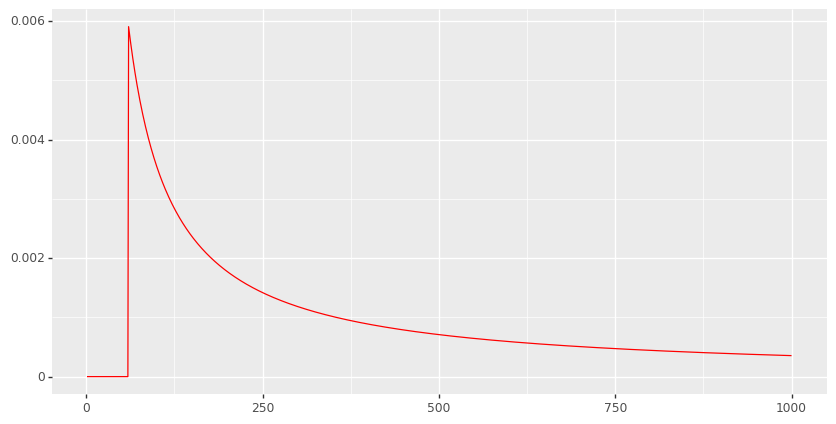

In [13]:
(ggplot() + 
 geom_line(posterior >> toXsPs >> withKeys >> ('x', 'y') >> toPandas, aes(x="x", y="y"), color='red') +
 theme(figure_size=(10,5), axis_title_x=element_blank(), axis_title_y=element_blank())
) >> PP;

hmmm... that's quite a heavy tail...

In [14]:
@coppertop
def pmfReport(pmf, lower, upper):
    c = pmf >> to >> CMF
    return f'{lower * 100:.0f}%={c >> quantile(_, lower):.0f}, µ={pmf >> mean:.1f}, median={c >> quantile(_, 0.5):.1f}, {upper * 100:.0f}%={c >> quantile(_, upper):.0f}'

@coppertop
def pmfReport(pmf, lower, upper, scale):
    c = pmf >> to >> CMF
    return f'{lower * 100:.0f}%={(c >> quantile(_, lower)) * scale:.0f}, µ={(pmf >> mean) * scale:.1f}, median={(c >> quantile(_, 0.5)) * scale:.1f}, {upper * 100:.0f}%={(c >> quantile(_, upper)) * scale:.0f}'

In [15]:
[250, 500, 1000, 2000, 4000] >> collect >> (lambda N: 
    sequence(1, N) 
        >> uniform
        >> pmfMul 
        >> railroadLikelihood(N, data)
        >> normalise 
        >> asUnary(lambda m: f'{N >> to >> txt >> pad(_, dict(right=4))}, {m >> pmfReport(_,0.05, 0.95)}')     
        >> PP
);

 250, 5%=64, µ=132.9, median=122.0, 95%=233
 500, 5%=66, µ=207.1, median=173.0, 95%=450
1000, 5%=69, µ=333.4, median=244.0, 95%=869
2000, 5%=71, µ=552.2, median=345.0, 95%=1678
4000, 5%=73, µ=936.5, median=488.0, 95%=3241


<br>

#### 3.4 An alternative prior

In fact, the distribution of company sizes tends to follow a power law, as Robert Axtell reports in Science (see http://www.sciencemag.org/content/293/5536/1818.full.pdf)

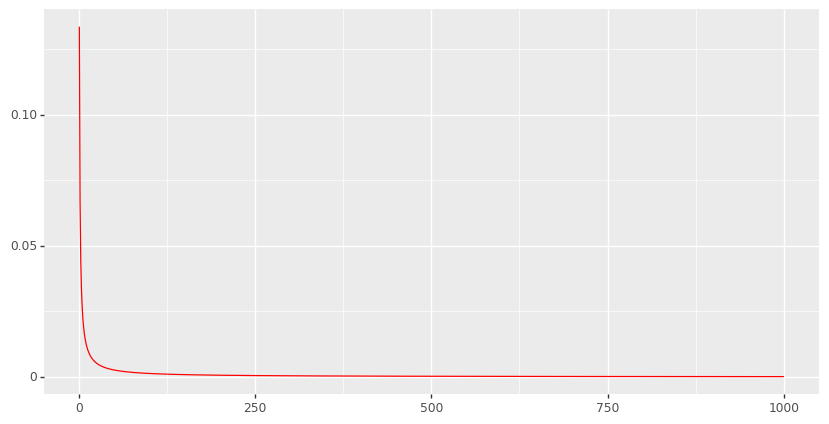

In [16]:
@coppertop
def powerLawPrior(N, alpha) -> PMF:
    return sequence(1, N) >> collect >> (lambda hyp: (hyp, hyp**(-alpha))) >> to >> PMF

(ggplot() + 
 geom_line(1000 >> powerLawPrior(_, 1) >> toXsPs >> withKeys >> ('x', 'y') >> toPandas, aes(x="x", y="y"), color='red') +
 theme(figure_size=(10,5), axis_title_x=element_blank(), axis_title_y=element_blank())
) >> PP;

<br>

#### 3.5 Credible intervals

In [17]:
observations = [30, 60, 90]
Ns = [250, 500, 1000, 2000, 4000]

Ns >> collect >> (lambda N: 
    powerLawPrior(N, 1.0)
        >> inject(observations, _, _) >> (lambda prior, ob:
            prior
                >> pmfMul 
                >> railroadLikelihood(N, ob)
                >> normalise 
        )
        >> asUnary(lambda pmf: f'{N >> to >> txt >> pad(_, dict(right=4))}, {pmf >> pmfReport(_,0.05, 0.95)}')
        >> PP
);

 250, 5%=91, µ=122.7, median=111.0, 95%=197
 500, 5%=91, µ=130.7, median=113.0, 95%=235
1000, 5%=91, µ=133.3, median=113.0, 95%=242
2000, 5%=91, µ=134.0, median=113.0, 95%=243
4000, 5%=91, µ=134.2, median=113.0, 95%=243


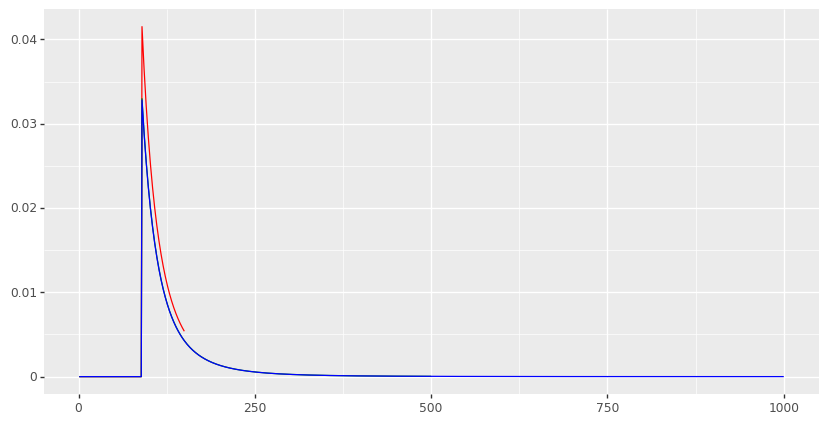

In [18]:
postfn = asUnary(lambda N: powerLawPrior(1000, 1.0)
        >> inject(observations, _, _) >> (lambda prior, ob:
            prior
                >> pmfMul 
                >> railroadLikelihood(N, ob)
                >> normalise 
        )
)

(ggplot() + 
 geom_line(150 >> postfn >> toXsPs >> withKeys >> ('x', 'y') >> toPandas, aes(x="x", y="y"), color='red') +
 geom_line(500 >> postfn >> toXsPs >> withKeys >> ('x', 'y') >> toPandas, aes(x="x", y="y"), color='green') +
 geom_line(1000 >> postfn >> toXsPs >> withKeys >> ('x', 'y') >> toPandas, aes(x="x", y="y"), color='blue') +
 theme(figure_size=(10,5), axis_title_x=element_blank(), axis_title_y=element_blank())
) >> PP;

_**Exercise 3.1.**_

_To write a likelihood function for the locomotive problem, we had to answer this question: “If the railroad has N 
locomotives, what is the probability that we see number 60?”_

_The answer depends on what sampling process we use when we observe the locomotive. In this chapter, I resolved the 
ambiguity by specifying that there is only one train-operating company (or only one that we care about)._

_But suppose instead that there are many companies with different numbers of trains. And suppose that you are equally 
likely to see any train operated by any company. In that case, the likelihood function is different because you are more
likely to see a train operated by a large company._

_As an exercise, implement the likelihood function for this variation of the locomotive problem, and compare the results._


Thinking out loud:

3 companies: 1 with 10 locomotives, 1 with 20, 1 with 30 \

chance of seeing a locomotive number 5 is (1/10 + 1/20 + 1/30) / total number of locomotives

#### 4.1 The Euro problem

A statistical statement appeared in “The Guardian" on Friday January 4, 2002:

When spun on edge 250 times, a Belgian one-euro coin
came up heads 140 times and tails 110. ‘It looks very
suspicious to me,’ said Barry Blight, a statistics lecturer
at the London School of Economics. ‘If the coin were
unbiased, the chance of getting a result as extreme as
that would be less than 7%.’

But do these data give evidence that the coin is biased rather
than fair?



#### Modelling the problem

Our model is the probability of heads between 0% an 100%. The likelihood of a head is the hypothesis value, the 
likelihood of a tail is 1 minus the hypothesis value. The prior is uniform, i.e. we assume that all hypotheses are 
equally likely.

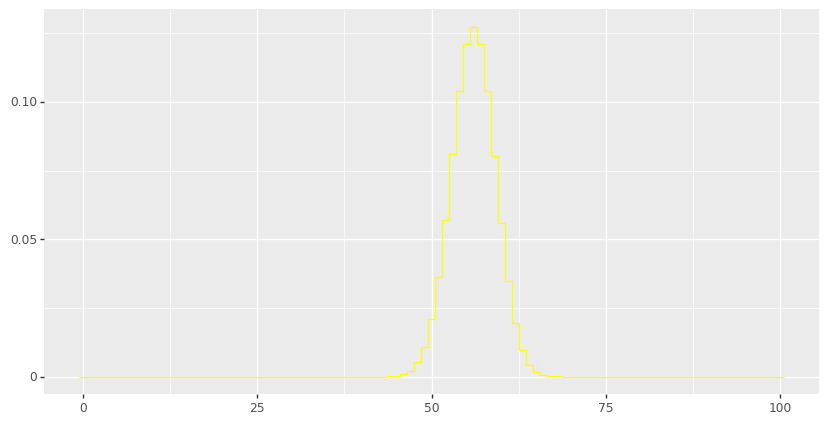

5%=51, µ=56.0, median=56.0, 95%=61
56.0


In [19]:
hypos = sequence(0, 100)

@coppertop
def euroLikelihood(hypos, ob) -> L:
    return (hypos >> collect >> 
        (lambda h: (h, h / 100.0) if ob == 'H' else (h, 1 - h / 100.0)) >>
        to >> L
    )

data = ['H'] * 140 + ['T'] * 110
prior = hypos >> uniform
posterior = data >> inject(_, prior, _) >> (lambda running, ob: running >> pmfMul >> euroLikelihood(hypos, ob)) >> normalise

(ggplot() + 
 geom_prob(posterior, dict(color='yellow')) +
 theme(figure_size=(10,5), axis_title_x=element_blank(), axis_title_y=element_blank())
) >> PP
posterior >> pmfReport(_, 0.05, 0.95) >> PP
posterior >> maxLikelihood >>  PP;

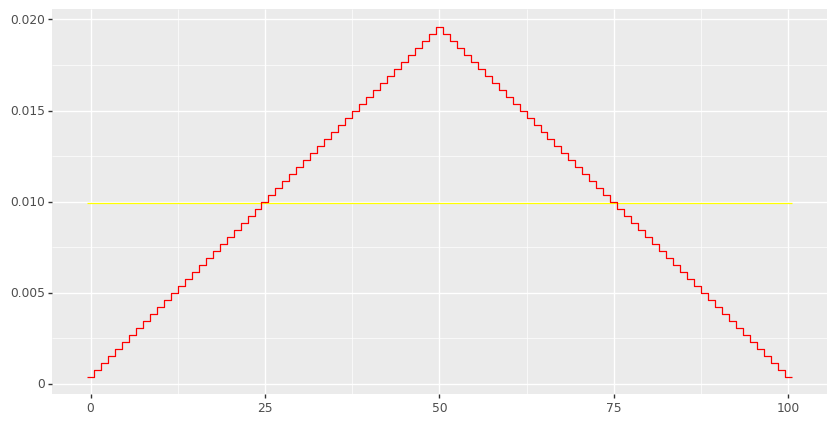

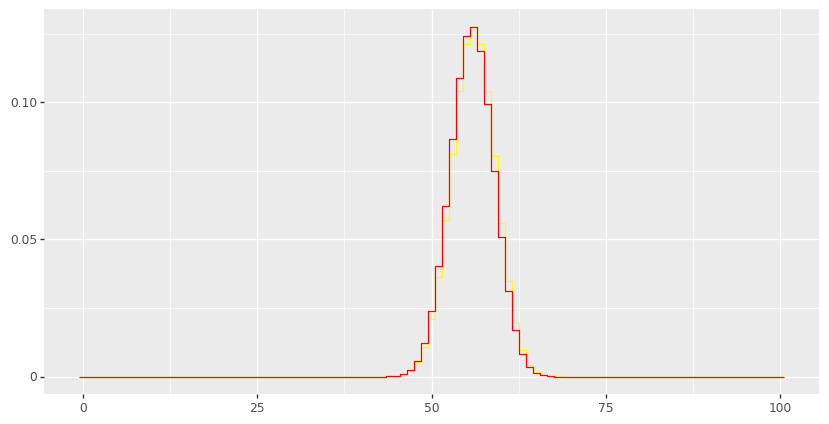

In [20]:
@coppertop
def triangular(seq) -> PMF:
    f, s = {}, (seq >> count) / 2 >> roundDown
    y = 1
    for x in seq[:s]:
        f[x] = y
        y += 1
    if (seq >> count) % 2 == 0: 
        # if odd number of elements, then the middle element just comes once
        y -= 1
    for x in seq[s:]:
        f[x] = y
        y -= 1
    return PMF(f)

prior2 = sequence(0, 100) >> triangular


(ggplot() + 
 geom_prob(prior, dict(color='yellow')) +
 geom_prob(prior2, dict(color='red')) +
 theme(figure_size=(10,5), axis_title_x=element_blank(), axis_title_y=element_blank())
) >> PP

posterior2 = data >> inject(_, prior2, _) >> (lambda running, ob: running >> pmfMul >> euroLikelihood(hypos, ob)) >> normalise
(ggplot() + 
 geom_prob(posterior, dict(color='yellow')) +
 geom_prob(posterior2, dict(color='red')) +
 theme(figure_size=(10,5), axis_title_x=element_blank(), axis_title_y=element_blank())
) >> PP

None;

#### 4.4 Optimisation

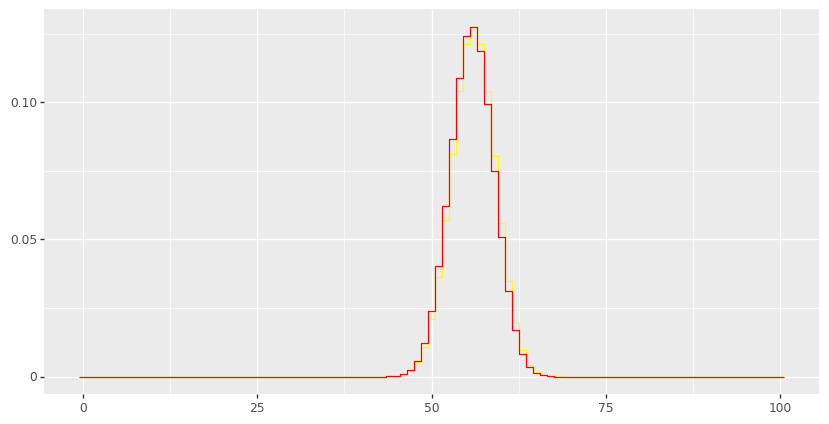

In [21]:
@coppertop
def euroLikelihoodHT(hypos, numHeads, numTails) -> L:
    return (hypos >> collect >> (
            lambda h: (h, (h / 100) ** numHeads * (1 - h / 100) ** numTails)
        ) >>
        to >> L
    )

posteria = sequence(0,100) >> uniform >> pmfMul >> euroLikelihoodHT(hypos, 140, 110) >> normalise
posteria2 = sequence(0,100) >> triangular >> pmfMul >> euroLikelihoodHT(hypos, 140, 110) >> normalise

(ggplot() + 
 geom_prob(posterior, dict(color='yellow')) +
 geom_prob(posterior2, dict(color='red')) +
 theme(figure_size=(10,5), axis_title_x=element_blank(), axis_title_y=element_blank())
) >> PP
None;

#### 4.5 beta distribution

https://en.wikipedia.org/wiki/Beta_distribution 
https://docs.scipy.org/doc/scipy/reference/generated/scipy.special.betainc.html



In [22]:
from bones.ts.metatypes import BType, extractConstructors
BetaDist = BType('BetaDist: BetaDist & {a:num, b:num} & dstruct in mem')

def _makeBeta(*args_, **kwargs_):
    constrs, args, kwargs = extractConstructors(args_, kwargs_)
    a = kwargs['a']
    b = kwargs['b']
    return dstruct(constrs[0], a=a, b=b)
BetaDist._constructor = Missing
BetaDist.setConstructor(_makeBeta)

import scipy.special

# OPEN: think through how to convert between PMF and CMF for discrete and approximations to continuous distributions as the following is unsatisfactory

@coppertop(style=binary)
def to(beta:BetaDist, t:CMF) -> CMF:
    a, b = beta.a, beta.b
    kvs = sequence(0, 1, dict(step=0.005)) >> collect >> (lambda x: (x, scipy.special.betainc(a, b, x)))
    return kvs >> to >> CMF


@coppertop(style=binary)
def to(cmf:CMF, t:PMF) -> PMF:
    f = {}
    prev = Missing
    for x, p in cmf.fn_.items():
        f[x] = p if prev is Missing else p - prev
        prev = p
    return PMF(f)

@coppertop(style=binary)
def to(beta:BetaDist, t:PMF) -> PMF:
    return beta >> to >> CMF >> to >> PMF

@coppertop
def mean(beta:BetaDist):
    """Returns the mean of the given BetaDist."""
    return beta.a / (beta.a + beta.b)

None;



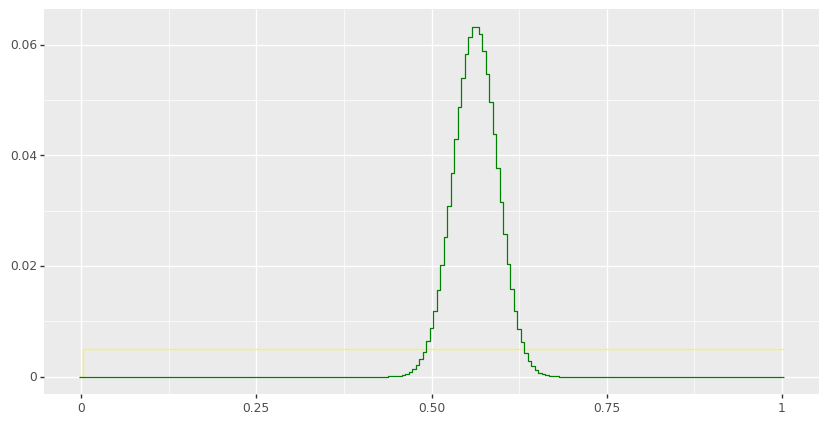

5%=51, µ=56.0, median=56.0, 95%=61
56.0


In [23]:
posteriorDist = BetaDist(a=140, b=110) 
posteriorPMF = posteriorDist >> to >> PMF

(ggplot() + 
 geom_prob(BetaDist(a=1, b=1) >> to >> CMF >> to >> PMF, dict(color='yellow')) +
 geom_prob(BetaDist(a=140, b=110) >> to >> CMF >> to >> PMF, dict(color='green')) +
 theme(figure_size=(10,5), axis_title_x=element_blank(), axis_title_y=element_blank())
) >> PP
posterior >> pmfReport(_, 0.05, 0.95) >> PP
posterior >> maxLikelihood >>  PP;

**Exercise 4.1.** 

_Suppose that instead of observing coin tosses directly, you measure the outcome using an instrument that is not always 
correct. Specifically, suppose there is a probability y that an actual heads is reported as tails, or actual tails 
reported as heads._

_Write a class that estimates the bias of a coin given a series of outcomes and the value of y._



Analysis:

Here Y is known and only affects the likelihood function. If y = 0 then the posterior should be the same as before. If 
y = 1, the measurement is a certain lie, then the posterior should be the exact opposite as before. If y = 0.5 then no 
result has any meaning so the posterior we tend towards up a uniform dist (depending on prior).


Uniform prior


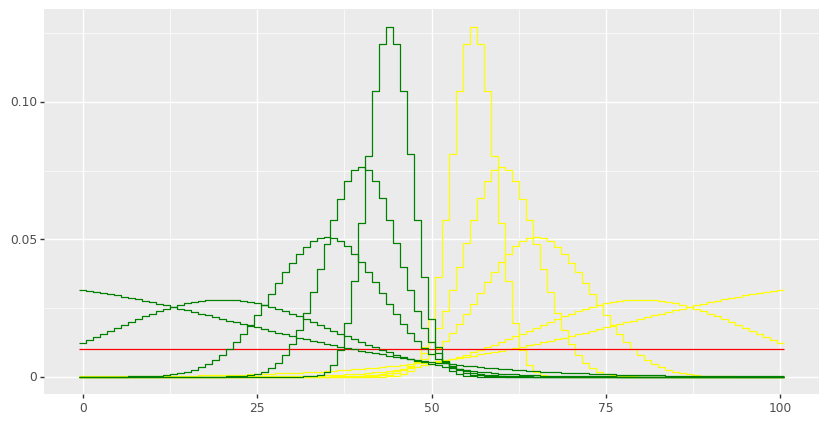


Triangular prior


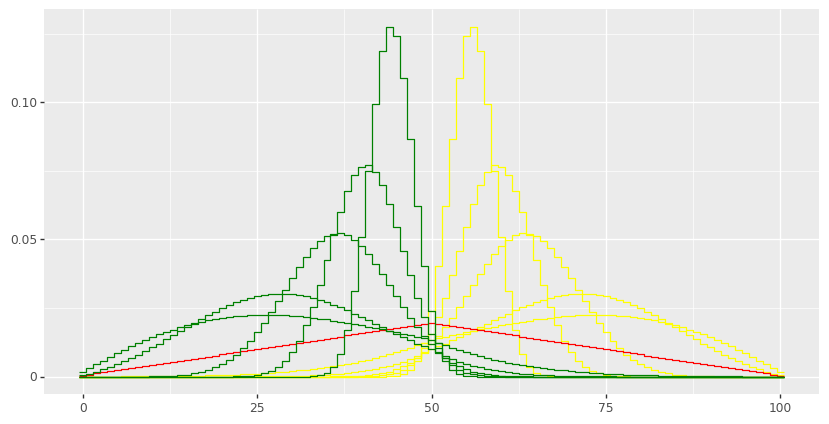

In [24]:
hypos = sequence(0, 100)

def likeOfHypEuroY(hyp, datum, Y):
    # likelihood of hypothesis pHead given the observation (datum) and Y
    if datum == 'H':
        return hyp * (1 - Y) + (1 - hyp) * Y    # if Y=0 then this gives the same result as before
    else:
        return (1 - hyp) * (1 - Y) + hyp * Y


@coppertop
def euroLikelihood(hypos, ob, Y) -> L:
    return (hypos >> collect >> 
        (lambda hyp: (hyp, likeOfHypEuroY(hyp/100, ob, Y))) >>
        to >> L
    )

data = ['H'] * 140 + ['T'] * 110


'Uniform prior' >> PP
prior = hypos >> uniform
(ggplot() + 
 geom_prob(posterior := data >> inject(_, prior, _) >> (lambda running, ob: running >> pmfMul >> euroLikelihood(hypos, ob, 0)) >> normalise, dict(color='yellow')) +
 geom_prob(posterior := data >> inject(_, prior, _) >> (lambda running, ob: running >> pmfMul >> euroLikelihood(hypos, ob, 0.2)) >> normalise, dict(color='yellow')) +
 geom_prob(posterior := data >> inject(_, prior, _) >> (lambda running, ob: running >> pmfMul >> euroLikelihood(hypos, ob, 0.3)) >> normalise, dict(color='yellow')) +
 geom_prob(posterior := data >> inject(_, prior, _) >> (lambda running, ob: running >> pmfMul >> euroLikelihood(hypos, ob, 0.4)) >> normalise, dict(color='yellow')) +
 geom_prob(posterior := data >> inject(_, prior, _) >> (lambda running, ob: running >> pmfMul >> euroLikelihood(hypos, ob, 0.45)) >> normalise, dict(color='yellow')) +
 geom_prob(posterior := data >> inject(_, prior, _) >> (lambda running, ob: running >> pmfMul >> euroLikelihood(hypos, ob, 0.5)) >> normalise, dict(color='red')) +
 geom_prob(posterior := data >> inject(_, prior, _) >> (lambda running, ob: running >> pmfMul >> euroLikelihood(hypos, ob, 0.55)) >> normalise, dict(color='green')) +
 geom_prob(posterior := data >> inject(_, prior, _) >> (lambda running, ob: running >> pmfMul >> euroLikelihood(hypos, ob, 0.6)) >> normalise, dict(color='green')) +
 geom_prob(posterior := data >> inject(_, prior, _) >> (lambda running, ob: running >> pmfMul >> euroLikelihood(hypos, ob, 0.7)) >> normalise, dict(color='green')) +
 geom_prob(posterior := data >> inject(_, prior, _) >> (lambda running, ob: running >> pmfMul >> euroLikelihood(hypos, ob, 0.8)) >> normalise, dict(color='green')) +
 geom_prob(posterior := data >> inject(_, prior, _) >> (lambda running, ob: running >> pmfMul >> euroLikelihood(hypos, ob, 1.0)) >> normalise, dict(color='green')) +
 theme(figure_size=(10,5), axis_title_x=element_blank(), axis_title_y=element_blank())
) >> PP;

'\nTriangular prior' >> PP
prior = hypos >> triangular
(ggplot() + 
 geom_prob(posterior := data >> inject(_, prior, _) >> (lambda running, ob: running >> pmfMul >> euroLikelihood(hypos, ob, 0)) >> normalise, dict(color='yellow')) +
 geom_prob(posterior := data >> inject(_, prior, _) >> (lambda running, ob: running >> pmfMul >> euroLikelihood(hypos, ob, 0.2)) >> normalise, dict(color='yellow')) +
 geom_prob(posterior := data >> inject(_, prior, _) >> (lambda running, ob: running >> pmfMul >> euroLikelihood(hypos, ob, 0.3)) >> normalise, dict(color='yellow')) +
 geom_prob(posterior := data >> inject(_, prior, _) >> (lambda running, ob: running >> pmfMul >> euroLikelihood(hypos, ob, 0.4)) >> normalise, dict(color='yellow')) +
 geom_prob(posterior := data >> inject(_, prior, _) >> (lambda running, ob: running >> pmfMul >> euroLikelihood(hypos, ob, 0.45)) >> normalise, dict(color='yellow')) +
 geom_prob(posterior := data >> inject(_, prior, _) >> (lambda running, ob: running >> pmfMul >> euroLikelihood(hypos, ob, 0.5)) >> normalise, dict(color='red')) +
 geom_prob(posterior := data >> inject(_, prior, _) >> (lambda running, ob: running >> pmfMul >> euroLikelihood(hypos, ob, 0.55)) >> normalise, dict(color='green')) +
 geom_prob(posterior := data >> inject(_, prior, _) >> (lambda running, ob: running >> pmfMul >> euroLikelihood(hypos, ob, 0.6)) >> normalise, dict(color='green')) +
 geom_prob(posterior := data >> inject(_, prior, _) >> (lambda running, ob: running >> pmfMul >> euroLikelihood(hypos, ob, 0.7)) >> normalise, dict(color='green')) +
 geom_prob(posterior := data >> inject(_, prior, _) >> (lambda running, ob: running >> pmfMul >> euroLikelihood(hypos, ob, 0.8)) >> normalise, dict(color='green')) +
 geom_prob(posterior := data >> inject(_, prior, _) >> (lambda running, ob: running >> pmfMul >> euroLikelihood(hypos, ob, 1.0)) >> normalise, dict(color='green')) +
 theme(figure_size=(10,5), axis_title_x=element_blank(), axis_title_y=element_blank())
) >> PP;

**Exercise 4.2.**

_This exercise is inspired by a question posted by a “redditor” named dominosci on Reddit’s statistics “subreddit” at 
http: // reddit. com/ r/ statistics._

_Reddit is an online forum with many interest groups called subreddits. Users, called redditors, post links to online 
content and other web pages. Other redditors vote on the links, giving an “upvote” to high-quality links and a 
“downvote” to links that are bad or irrelevant._

_A problem, identified by dominosci, is that some redditors are more reliable than others, and Reddit does not take this 
into account. The challenge is to devise a system so that when a redditor casts a vote, the estimated quality of the 
link is updated in accordance with the reliability of the redditor, and the estimated reliability of the redditor is 
updated in accordance with the quality of the link._

_One approach is to model the quality of the link as the probability of garnering an upvote, and to model the 
reliability of the redditor as the probability of correctly giving an upvote to a high-quality item._

_Write class definitions for redditors and links and an update function that updates both objects whenever a redditor 
casts a vote._

**Analysis:**

Going with the "One approach"

How does 5 upvotes compare to 10 upvotes and 5 downvotes?

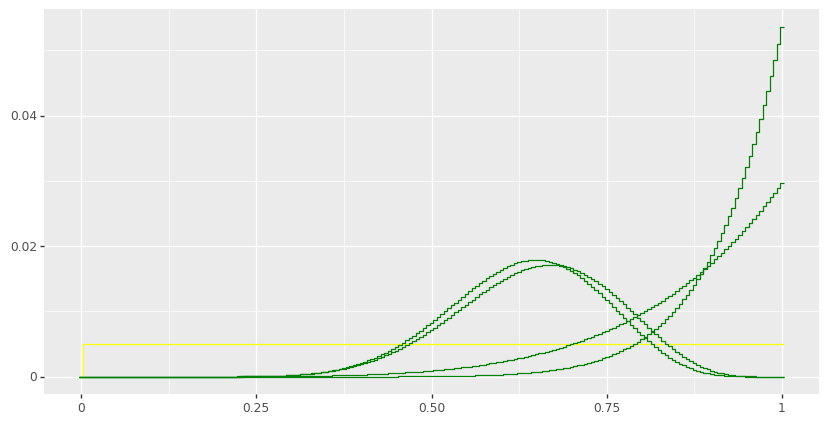

5%=5, µ=50.0, median=50.0, 95%=95
5%=61, µ=85.7, median=89.5, 95%=100
5%=76, µ=91.7, median=94.0, 95%=100
5%=46, µ=64.7, median=65.5, 95%=82
5%=45, µ=63.2, median=64.0, 95%=80


In [25]:
(ggplot() + 
 geom_prob(BetaDist(a=1, b=1) >> to >> CMF >> to >> PMF, dict(color='yellow')) +
 geom_prob(BetaDist(a=6, b=1) >> to >> CMF >> to >> PMF, dict(color='green')) +
 geom_prob(BetaDist(a=11, b=1) >> to >> CMF >> to >> PMF, dict(color='green')) +
 geom_prob(BetaDist(a=11, b=6) >> to >> CMF >> to >> PMF, dict(color='green')) +
 geom_prob(BetaDist(a=12, b=7) >> to >> CMF >> to >> PMF, dict(color='green')) +
 theme(figure_size=(10,5), axis_title_x=element_blank(), axis_title_y=element_blank())
) >> PP;
BetaDist(a=1, b=1) >> pmfReport(_, 0.05, 0.95, 100) >> PP;
BetaDist(a=6, b=1) >> pmfReport(_, 0.05, 0.95, 100) >> PP;
BetaDist(a=11, b=1) >> pmfReport(_, 0.05, 0.95, 100) >> PP;
BetaDist(a=11, b=6) >> pmfReport(_, 0.05, 0.95, 100) >> PP;
BetaDist(a=12, b=7) >> pmfReport(_, 0.05, 0.95, 100) >> PP;


In [26]:
"Going with the One approach"


U = prob of getting an upvote

reditorReliability is a PMF - the probability of giving an upvote on a good link
link is probability of good link

link quality = prob of getting an upvote (is that out of all votes? ratio of upvotes to )

link
hypLink is pUpvote, prior = uniform

quality = maxLikelihood of pUpvote

redditor
hypReliability is pUpvote given high quality





SyntaxError: invalid syntax (2731602708.py, line 4)

IDEAL ERRORS

"hello" >> toCmf

```
Can't find toCmf(str) in:
  toCmf(pmf:(adhoc + (t514 & _numEtAl & _PMF))) in dm.pmf
```

ideally

```
DispatchError: Can't find toCmf(str) in:
  toCmf(pmf:PMF+adhoc) -> any    in dm.pmf[176]
---------------------------------------------------------------------------
Traceback (most recent call last)

<ipython-input-26-8a7f9c734ab9> in <module>
----> 1 "hello" >> toCmf
```